# Predicción de Abandono Escolar y Éxito Académico
### Universidad Nacional — Sede Regional Brunca, Campus Pérez Zeledón
**Curso:** Inteligencia Artificial  
**Profesor:** Pablo Andrés Venegas Elizondo  
**Integrantes:** Altamirano Cordero Deyaneira, Mata Flores Yenifer, Ortiz Molina Jordan

**Fecha:** Junio 2026


## 1. Introducción y Planteamiento del Problema


### 1.1 Introducción

El abandono escolar universitario es un problema que afecta a instituciones 
educativas de todo el mundo. No todos los estudiantes que inician una carrera 
logran terminarla, y las causas pueden ser muy diversas: dificultades 
económicas, bajo rendimiento académico, problemas personales o una combinación 
de estos factores.

Tradicionalmente, detectar a un estudiante en riesgo dependía de la 
experiencia del personal académico o de que el problema ya fuera visible — 
muchas veces demasiado tarde para intervenir efectivamente.

La Inteligencia Artificial, específicamente el aprendizaje automático 
(Machine Learning), ofrece una alternativa: analizar patrones en datos 
históricos de estudiantes para predecir, de forma temprana, cuáles tienen 
mayor probabilidad de abandonar. Esto le permite a la institución actuar 
antes de que el abandono ocurra, ya sea mediante apoyo económico, tutoría 
académica u orientación personalizada.

Este proyecto desarrolla un sistema de clasificación que predice si un 
estudiante va a abandonar su carrera, continuar matriculado o graduarse, 
funcionando como una herramienta de apoyo a la toma de decisiones 
institucionales.

### 1.1 Contexto del Dataset

Se utiliza un conjunto de datos proveniente de una institución de educación 
superior de Portugal, creado a partir de múltiples bases de datos 
institucionales y puesto a disposición pública en diciembre de 2021 a través 
del repositorio UCI Machine Learning Repository.

El dataset contiene información de estudiantes matriculados en distintas 
titulaciones de grado: agronomía, diseño, educación, enfermería, periodismo, 
administración, servicios sociales y tecnologías, entre otras.

Los datos capturan tres tipos de información:
- **Trayectoria académica previa** al ingreso
- **Factores demográficos y socioeconómicos** del estudiante
- **Rendimiento académico** al finalizar el primer y segundo semestre

### 1.2 Definición del Problema

El problema se formula como una tarea de **clasificación supervisada 
multiclase**. A partir de información demográfica, socioeconómica y del 
rendimiento académico del primer y segundo semestre, el modelo predice 
la situación final del estudiante en una de tres categorías:

- **Dropout**: el estudiante abandonó la carrera
- **Enrolled**: el estudiante continúa matriculado activo
- **Graduate**: el estudiante completó y se graduó

**Variables de entrada (features):** las 36 características del dataset,
que incluyen datos demográficos, socioeconómicos y rendimiento académico
de los dos primeros semestres.

**Variable de salida (target):** la columna `Target`, que indica la 
situación final del estudiante.

**Objetivo del modelo:** predecir la categoría más probable para un 
estudiante dado, con el fin de identificar tempranamente casos de riesgo 
de abandono y apoyar la toma de decisiones institucionales.

### 1.3 Tipo de Aprendizaje

Este problema corresponde a **aprendizaje supervisado**, ya que el dataset 
cuenta con ejemplos etiquetados — para cada estudiante ya se conoce el 
resultado final (Dropout, Enrolled o Graduate). El modelo aprende a partir 
de esos ejemplos históricos para luego predecir casos nuevos.

Dentro del aprendizaje supervisado, se trata específicamente de 
**clasificación multiclase**, porque la variable de salida no es un número 
continuo sino una categoría discreta con tres posibles valores.

### 1.4 Variables de entrada y salida

**Variables de entrada (features):** el modelo recibe 36 características 
por estudiante, agrupadas en tres categorías:

- **Demográficas y socioeconómicas:** edad al matricularse, género, 
  nacionalidad, estado civil, si es becado, si tiene deudas de matrícula, 
  ocupación y nivel educativo de los padres, entre otras.

- **Académicas previas al ingreso:** modalidad de aplicación, orden de 
  preferencia, carrera elegida, calificación de admisión y 
  cualificación previa.

- **Rendimiento académico:** unidades curriculares matriculadas, 
  aprobadas, evaluadas y calificaciones del primer y segundo semestre.

**Variable de salida (target):** la columna `Target`, que indica la 
situación final del estudiante en una de tres categorías: `Dropout`, 
`Enrolled` o `Graduate`.

### 1.5 Justificación del Enfoque

Se seleccionaron dos modelos de clasificación para abordar este problema:

**Random Forest** es un algoritmo basado en la construcción de múltiples 
árboles de decisión que combinan sus resultados para producir una predicción 
final. Es adecuado para este problema porque maneja simultáneamente variables 
numéricas y categóricas, es resistente al sobreajuste gracias a la 
agregación de múltiples árboles, y permite obtener la importancia relativa 
de cada variable — lo cual es valioso para entender qué factores influyen 
más en el abandono escolar.

**Regresión Logística** es un modelo lineal que estima la probabilidad de 
pertenencia a cada clase. Se incluye este modelo porque es interpretable 
matemáticamente, computacionalmente eficiente y establece un punto de 
referencia mínimo que cualquier modelo más complejo debería superar.

La comparación entre ambos permite evaluar si la complejidad adicional 
del Random Forest se traduce en una mejora real sobre un modelo lineal 
más simple.

#### Configuración inicial
En esta celda se importan las librerías necesarias y se carga el dataset.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Descripción del Dataset



### 2.1 Descripción General


Se utiliza un conjunto de datos proveniente de una institución de educación 
superior de Portugal, creado a partir de múltiples bases de datos 
institucionales y puesto a disposición pública en diciembre de 2021 a través 
del repositorio UCI Machine Learning Repository.

El dataset contiene **4,424 registros** y **37 columnas** — 36 variables 
de entrada y 1 variable objetivo. Cada fila representa un estudiante único 
matriculado en una institución de educación superior de Portugal en 
titulaciones de grado como agronomía, diseño, educación, enfermería, 
periodismo, administración, servicios sociales y tecnologías, entre otras.

No contiene valores nulos, lo que simplifica el proceso de limpieza, 
aunque sí presenta desbalance entre las clases de la variable objetivo,
aspecto que se analizará en detalle durante el análisis exploratorio.


### 2.2 Identificación de Variables

A continuación se detalla cada variable del dataset agrupada según 
su naturaleza. Esta clasificación es fundamental para el preprocesamiento, 
ya que cada grupo requiere un tratamiento diferente.

**Variables demográficas y personales**
- `Marital status` — estado civil del estudiante
- `Gender` — género (0: femenino, 1: masculino)
- `Age at enrollment` — edad al momento de matricularse
- `Nacionality` — nacionalidad
- `International` — si es estudiante internacional (0: no, 1: sí)
- `Displaced` — si vive fuera de su lugar de origen (0: no, 1: sí)

**Variables socioeconómicas**
- `Mother's qualification` — nivel educativo de la madre
- `Father's qualification` — nivel educativo del padre
- `Mother's occupation` — ocupación de la madre
- `Father's occupation` — ocupación del padre
- `Scholarship holder` — si posee beca (0: no, 1: sí)
- `Debtor` — si tiene deudas pendientes (0: no, 1: sí)
- `Tuition fees up to date` — si está al día con el pago de matrícula (0: no, 1: sí)
- `Educational special needs` — si tiene necesidades educativas especiales (0: no, 1: sí)
- `Unemployment rate` — tasa de desempleo del país al momento de matrícula
- `Inflation rate` — tasa de inflación
- `GDP` — producto interno bruto

**Variables académicas previas al ingreso**
- `Application mode` — modalidad de aplicación a la carrera
- `Application order` — orden de preferencia de la carrera
- `Course` — carrera matriculada
- `Previous qualification` — nivel de cualificación previa
- `Previous qualification (grade)` — nota de la cualificación previa
- `Admission grade` — nota de admisión
- `Daytime/evening attendance` — si asiste en horario diurno o nocturno

**Rendimiento académico**
- `Curricular units 1st sem (credited)` — unidades reconocidas 1er semestre
- `Curricular units 1st sem (enrolled)` — unidades matriculadas 1er semestre
- `Curricular units 1st sem (evaluations)` — unidades evaluadas 1er semestre
- `Curricular units 1st sem (approved)` — unidades aprobadas 1er semestre
- `Curricular units 1st sem (grade)` — promedio de notas 1er semestre
- `Curricular units 1st sem (without evaluations)` — unidades sin evaluación 1er semestre
- `Curricular units 2nd sem (credited)` — unidades reconocidas 2do semestre
- `Curricular units 2nd sem (enrolled)` — unidades matriculadas 2do semestre
- `Curricular units 2nd sem (evaluations)` — unidades evaluadas 2do semestre
- `Curricular units 2nd sem (approved)` — unidades aprobadas 2do semestre
- `Curricular units 2nd sem (grade)` — promedio de notas 2do semestre
- `Curricular units 2nd sem (without evaluations)` — unidades sin evaluación 2do semestre

**Variable objetivo**
- `Target` — situación final del estudiante: `Dropout`, `Enrolled` o `Graduate`


### 2.3 Análisis exploratorio


#### 2.3.1 Inspección Inicial
Antes de analizar las variables individualmente, se realiza una 
inspección general del dataset para verificar su estructura, tipos 
de datos, valores nulos y registros duplicados.

In [26]:
# Estructura general
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nRegistros duplicados:", df.duplicated().sum())

Dimensiones: (4424, 37)

Tipos de datos:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date        

#### Interpretación

La inspección inicial revela que el dataset está en buenas condiciones 
para el análisis:

**Sin valores nulos:** todas las columnas presentan 4,424 registros 
completos, lo que elimina la necesidad de imputación de datos faltantes.

**Sin duplicados:** no se encontraron registros repetidos, por lo que 
no es necesario eliminar filas.

**Tipos de datos:** se identifica que todas las variables están 
almacenadas como tipos numéricos (`int64` o `float64`). Sin embargo, 
no todas representan valores numéricos reales, varias columnas 
contienen códigos enteros que representan categorías. 

#### Estadísticas Descriptivas

Para comprender el comportamiento general de las variables numéricas 
del dataset, se analizan sus estadísticas descriptivas básicas. Esto 
permite identificar rangos de valores, posibles outliers y variables 
con poca variabilidad que podrían no aportar información útil al modelo.

In [28]:
df.describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


#### Interpretación

El análisis descriptivo revela varios aspectos importantes del dataset:

**Variables con baja variabilidad:** algunas variables presentan un valor 
dominante en la mayoría de registros, lo que podría limitar su capacidad 
predictiva. Los casos más extremos son `Educational special needs` (98.8%), 
`Nacionality` (97.5%) e `International` (97.5%). Estas variables serán 
analizadas en detalle durante el preprocesamiento para evaluar si deben 
ser eliminadas.

**Variables con códigos numéricos:** columnas como `Course`, `Application mode` 
y `Marital status` contienen códigos numéricos que representan categorías, 
no valores continuos. Esto debe considerarse durante el preprocesamiento 
para tratarlas correctamente.

**Variables económicas:** `GDP` presenta valores negativos y `Inflation rate` 
muestra alta variación, lo cual es esperado dado que reflejan condiciones 
macroeconómicas reales del período de estudio.

#### Identificación de Tipos de Variables

Todas las variables están 
almacenadas como tipos numéricos. Sin embargo, no todas representan 
valores numéricos reales, varias columnas contienen códigos enteros 
que representan categorías discretas.

A continuación se verifica la naturaleza de cada variable categórica 
revisando sus valores únicos:

In [27]:
categoricas = [
    'Marital status', 'Application mode', 'Application order',
    'Course', 'Daytime/evening attendance\t', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Gender', 'Scholarship holder', 'International'
]

numericas = [
    'Previous qualification (grade)', 'Admission grade',
    'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)'
]

for col in categoricas:
    print(f"{col}: {sorted(df[col].unique())}")

Marital status: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Application mode: [np.int64(1), np.int64(2), np.int64(5), np.int64(7), np.int64(10), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(26), np.int64(27), np.int64(39), np.int64(42), np.int64(43), np.int64(44), np.int64(51), np.int64(53), np.int64(57)]
Application order: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9)]
Course: [np.int64(33), np.int64(171), np.int64(8014), np.int64(9003), np.int64(9070), np.int64(9085), np.int64(9119), np.int64(9130), np.int64(9147), np.int64(9238), np.int64(9254), np.int64(9500), np.int64(9556), np.int64(9670), np.int64(9773), np.int64(9853), np.int64(9991)]
Daytime/evening attendance	: [np.int64(0), np.int64(1)]
Previous qualification: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(12), np.int64(14), np.int64(15), np.int64

#### Interpretación

Se identifican dos grupos de variables según su naturaleza real:

**Variables categóricas (18):** almacenadas como enteros pero representan 
categorías discretas. Dentro de este grupo existen dos subtipos:
- **Binarias:** `Gender`, `Displaced`, `Debtor`, `Tuition fees up to date`, 
  `Scholarship holder`, `International`, `Educational special needs` y 
  `Daytime/evening attendance` — usan códigos 0 y 1.
- **Multiclase:** `Marital status`, `Course`, `Application mode`, 
  `Nacionality`, `Mother's occupation`, `Father's occupation`, entre otras 
  — usan múltiples códigos enteros para representar categorías distintas.

**Variables numéricas (16):** representan valores continuos reales como 
notas, edad, tasas económicas y conteos de unidades curriculares.

Cada grupo 
requiere un tratamiento diferente en el pipeline de transformación.

#### 2.3.2 Análisis Univariado

#### Distribución de la variable objetivo

Antes de cualquier análisis, es fundamental entender cómo se distribuyen 
las clases de la variable objetivo. Un desbalance significativo entre clases 
afecta directamente la elección de métricas de evaluación y la estrategia 
de entrenamiento de los modelos.

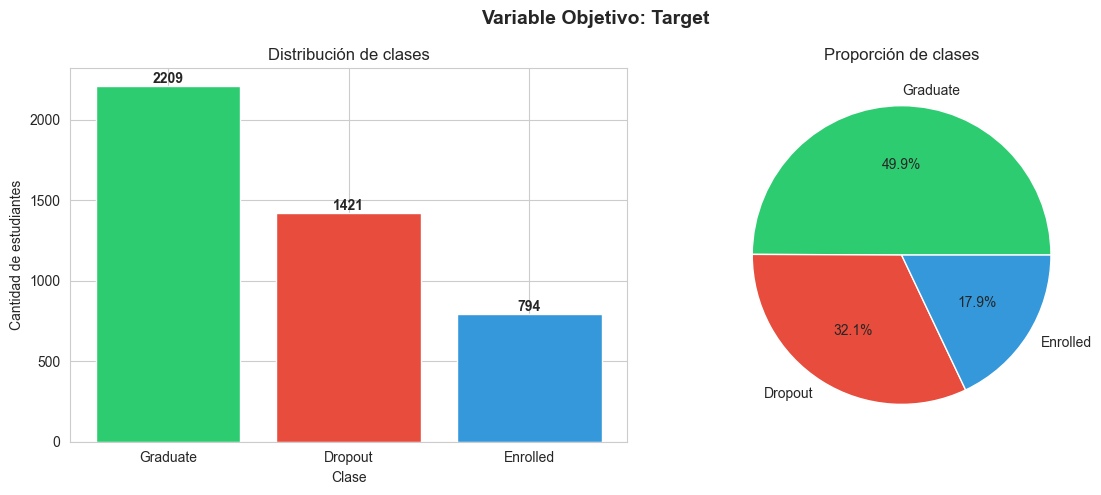

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
conteo = df['Target'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Distribución de clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de estudiantes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title('Proporción de clases')

plt.suptitle('Variable Objetivo: Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(conteo)

#### Interpretación

El dataset presenta un desbalance de clases considerable. La clase 
**Graduate** domina con un 49.9% de los registros, seguida de **Dropout** 
con 32.1% y **Enrolled** con apenas 17.9%.

Este desbalance es relevante porque un modelo que predijera "Graduate" 
para todos los estudiantes obtendría un 49.9% de accuracy sin haber 
aprendido nada útil, casi la mitad de aciertos garantizados por la 
distribución del dataset, no por el aprendizaje del modelo. Esto hace 
que el accuracy no sea una métrica confiable para evaluar el desempeño 
en este problema.

Por esta razón se tomarán dos decisiones técnicas:
- Se utilizará el **F1-score macro** como métrica principal, ya que 
  evalúa el desempeño en cada clase por separado con igual peso, 
  independientemente de su frecuencia.
- Se aplicará **class_weight='balanced'** durante el entrenamiento, 
  para que los modelos no aprendan a favorecer la clase mayoritaria.

#### Distribución de Variables Numéricas Continuas

Se analizan las distribuciones de las variables numéricas continuas 
del dataset para identificar asimetrías, outliers y rangos de valores. 
Esto informa las decisiones de escalamiento durante el preprocesamiento.

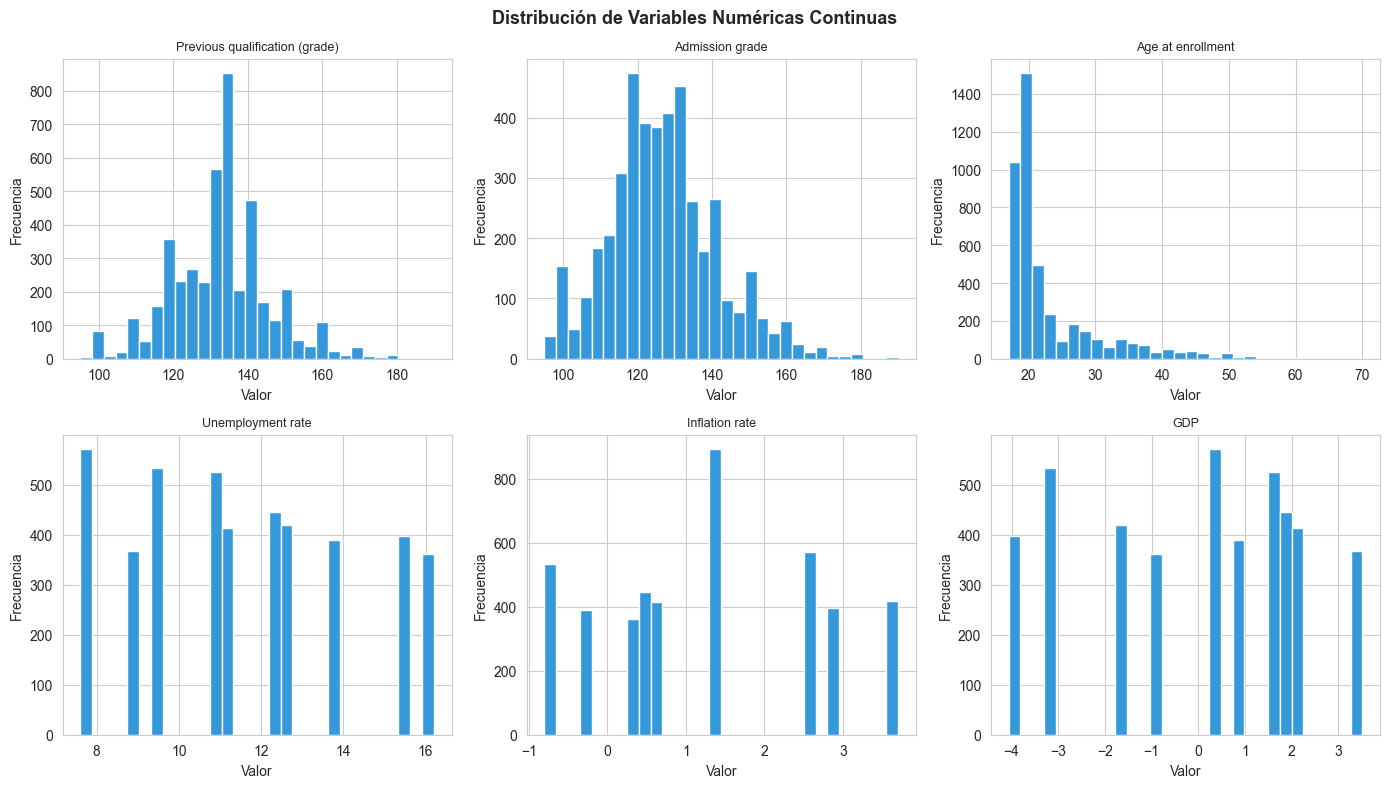

In [15]:
# Variables numéricas continuas generales
continuas = ['Previous qualification (grade)', 'Admission grade',
             'Age at enrollment', 'Unemployment rate', 
             'Inflation rate', 'GDP']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(continuas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Continuas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Notas de admisión y cualificación previa:** ambas presentan distribuciones 
aproximadamente normales concentradas entre 120 y 150, lo que sugiere 
un proceso de admisión con criterios consistentes. La similitud entre 
ambas distribuciones indica que los estudiantes ingresan con un perfil 
académico previo relativamente homogéneo.

**Edad al matricularse:** la distribución está fuertemente concentrada 
entre 17 y 25 años con una cola larga hacia edades mayores. La presencia 
de estudiantes mayores de 40 años podría representar un perfil con 
dinámicas de abandono distintas, asociadas a responsabilidades laborales 
o familiares.

**Variables macroeconómicas (Unemployment rate, Inflation rate, GDP):** 
las tres presentan distribuciones discretas con pocos valores únicos. 
Esto se debe a que reflejan el contexto económico del país en períodos 
específicos — varios estudiantes comparten el mismo valor por haber 
ingresado en el mismo año. Dado que sus escalas son muy diferentes 
entre sí, estas variables requerirán escalamiento durante el 
preprocesamiento.

#### Distribución de Variables Académicas

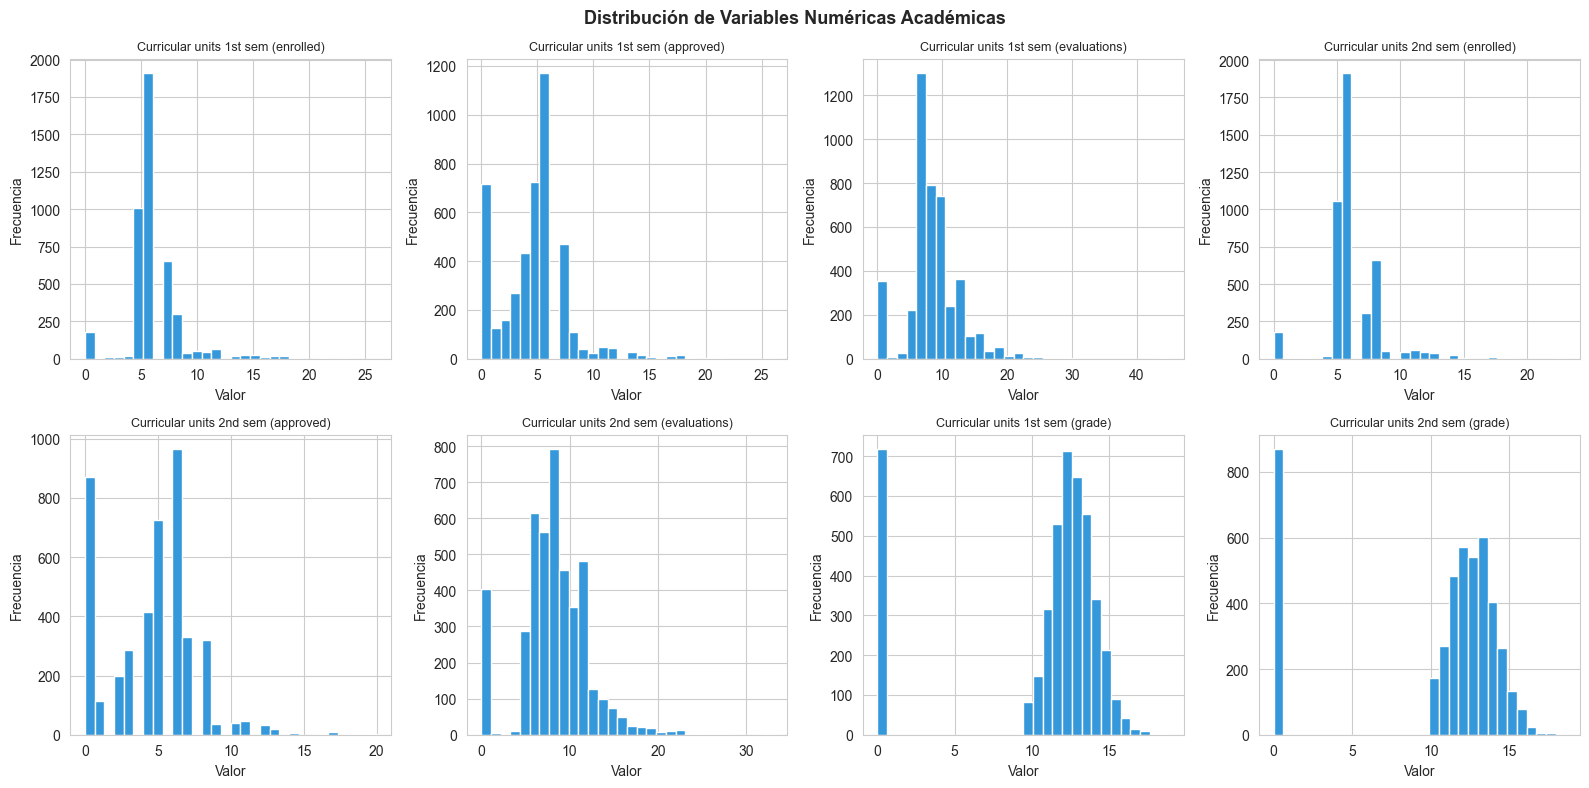

In [14]:
academicas = [
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (grade)',
             'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(academicas):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Académicas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Unidades matriculadas (enrolled):** tanto en el primer como en el 
segundo semestre, la mayoría de estudiantes se matricula en 6 materias, 
con una distribución similar entre ambos semestres. Esto sugiere una 
carga académica estándar para la mayoría.

**Unidades aprobadas (approved):** esta es la variable más reveladora. 
Se observan dos grupos claramente distintos, un grupo que aprueba 
entre 5 y 6 materias, y un grupo significativo con 0 materias aprobadas. 
Esta bimodalidad sugiere una división clara entre estudiantes que 
avanzan normalmente y estudiantes en riesgo de abandono. En el segundo 
semestre el pico en 0 es proporcionalmente mayor, lo que podría indicar 
que quienes no aprobaron en el primero tampoco logran recuperarse.

**Unidades evaluadas (evaluations):** la mayoría fue evaluada entre 
8 y 10 veces, sin embargo el pico inicial en valores bajos sugiere 
estudiantes que dejaron de presentarse a evaluaciones, comportamiento 
consistente con abandono temprano.

**Notas del semestre (grade):** el pico prominente en 0 confirma lo 
observado en approved, un grupo importante de estudiantes termina 
el semestre sin ninguna nota aprobatoria. Estas variables junto con 
approved serán probablemente las más predictivas para el modelo.

#### Variables Categóricas

Se analiza la distribución de las variables categóricas principales 
para identificar desbalances y categorías dominantes que puedan 
afectar el modelo.

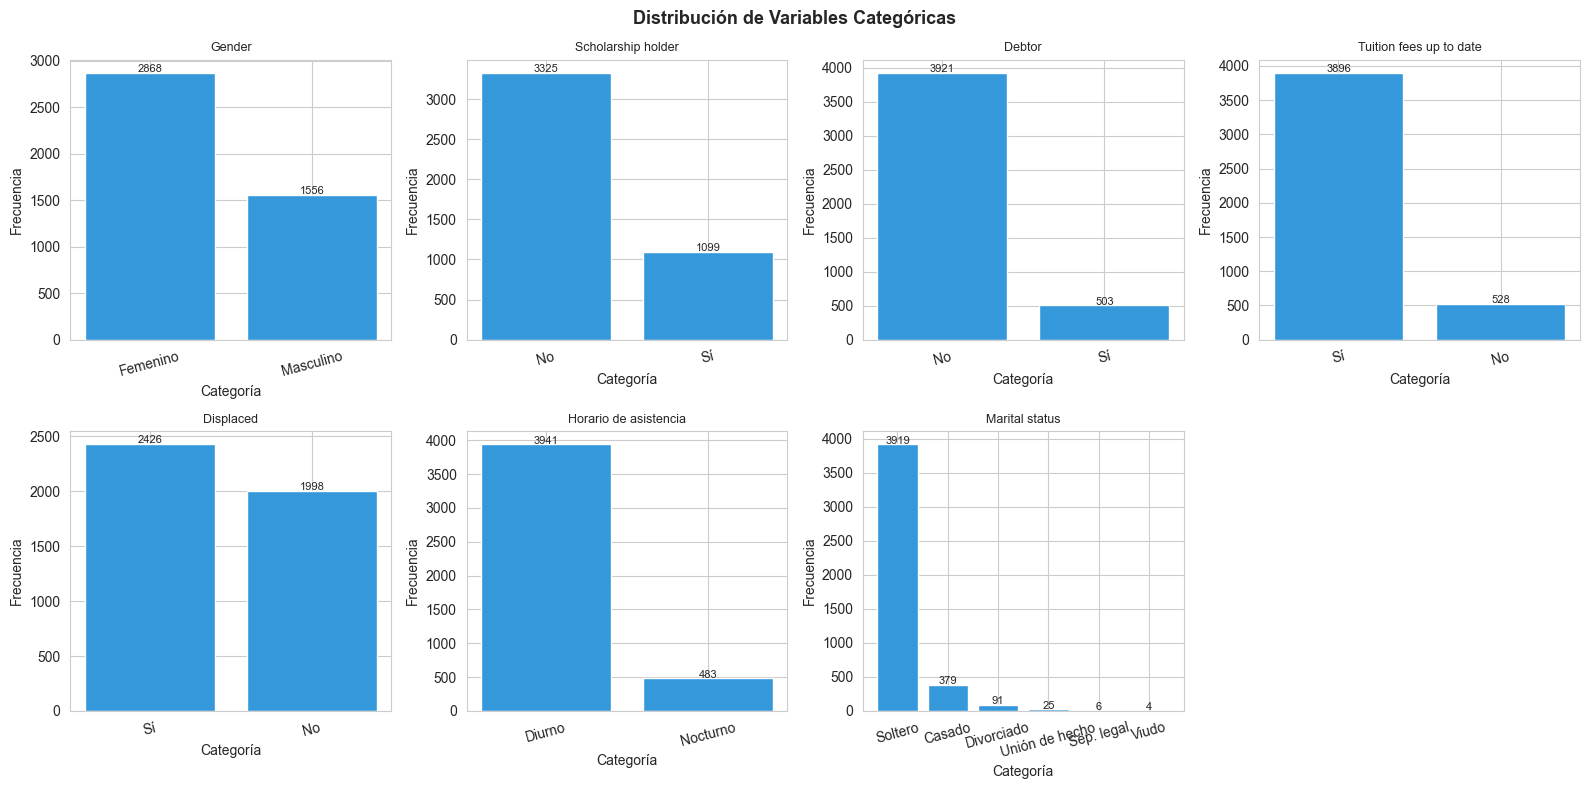

In [31]:
# Mapeo de códigos a etiquetas legibles
mapeos = {
    'Gender': {0: 'Femenino', 1: 'Masculino'},
    'Scholarship holder': {0: 'No', 1: 'Sí'},
    'Debtor': {0: 'No', 1: 'Sí'},
    'Tuition fees up to date': {0: 'No', 1: 'Sí'},
    'Displaced': {0: 'No', 1: 'Sí'},
    'Daytime/evening attendance\t': {0: 'Nocturno', 1: 'Diurno'},
    'Marital status': {1: 'Soltero', 2: 'Casado', 3: 'Viudo', 
                       4: 'Divorciado', 5: 'Unión de hecho', 
                       6: 'Sep. legal'}
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(mapeos.keys()):
    datos = df[col].map(mapeos[col]).value_counts()
    axes[i].bar(datos.index, datos.values, color='#3498db')
    axes[i].set_title(col.replace('Daytime/evening attendance\t', 
                      'Horario de asistencia'), fontsize=9)
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(datos.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribución de Variables Categóricas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

La mayoría de estudiantes son mujeres, solteras, asisten en horario 
diurno y no tienen deudas ni problemas con el pago de matrícula.

Los aspectos más relevantes para el modelo son:

**Beca:** solo el 24.8% de estudiantes tiene beca. Este grupo es 
importante porque perder la beca por bajo rendimiento puede 
convertirse en un factor acelerador del abandono.

**Dificultades económicas:** los estudiantes con deudas o que no 
están al día con la matrícula son minoría, pero representan un 
grupo de riesgo directo para el abandono.

**Horario nocturno:** los 483 estudiantes nocturnos frecuentemente 
combinan trabajo y estudio, lo que puede afectar negativamente 
su rendimiento académico.

**Estado civil:** el dominio casi absoluto de solteros (3,919 de 4,424) 
sugiere que esta variable tendrá poca capacidad discriminativa 
para el modelo — será candidata a eliminación en el preprocesamiento.

#### Detección de Outliers

Se utilizan diagramas de caja (boxplots) para identificar valores 
atípicos en las variables numéricas continuas. Los outliers pueden 
afectar el entrenamiento del modelo y deben ser analizados para 
decidir si representan errores o casos reales válidos.

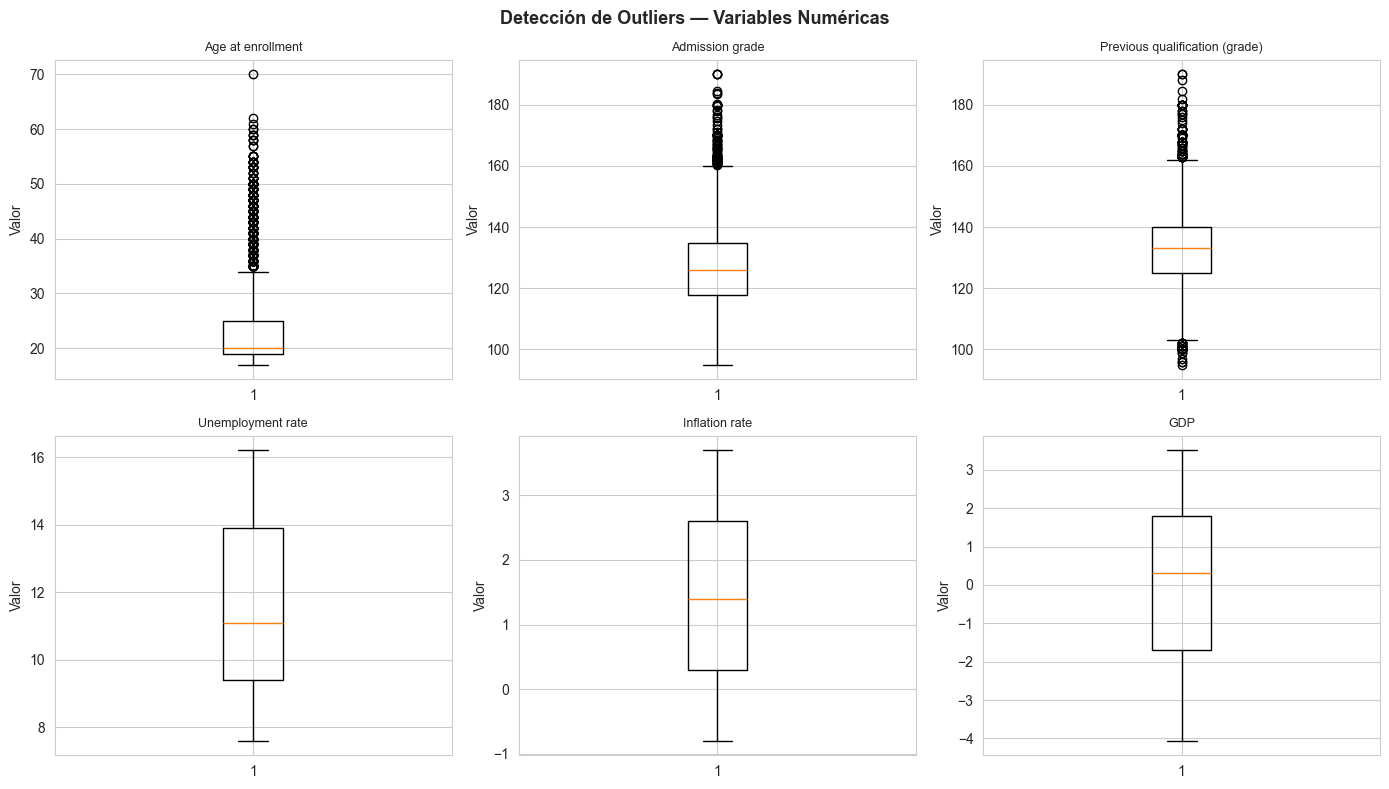

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

outlier_vars = ['Age at enrollment', 'Admission grade',
                'Previous qualification (grade)',
                'Unemployment rate', 'Inflation rate', 'GDP']

for i, col in enumerate(outlier_vars):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Valor')

plt.suptitle('Detección de Outliers — Variables Numéricas', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

El análisis de boxplots revela la presencia de valores atípicos en 
las variables académicas y de edad:

**Edad al matricularse:** la mayoría de estudiantes tiene entre 19 y 
25 años, sin embargo se identifican casos de estudiantes mayores de 
40, 50 e incluso 70 años. Estos valores son outliers estadísticos 
pero representan casos reales y válidos — estudiantes que retoman 
sus estudios en edad adulta. No se eliminan.

**Notas de admisión y cualificación previa:** la mayoría se concentra 
entre 120 y 140 puntos, con algunos casos excepcionales cercanos a 
190. Estas notas altas son perfectamente posibles dentro de la escala 
0-200 del sistema educativo portugués. No se eliminan.

**Variables macroeconómicas:** no se identifican outliers en tasa de 
desempleo, inflación ni GDP — sus distribuciones son consistentes 
con variaciones económicas reales del período de estudio.

En general, los outliers encontrados no representan errores de datos 
sino perfiles reales de estudiantes. Eliminarlos podría sesgar el 
modelo hacia un perfil estudiantil único, perdiendo capacidad 
predictiva para casos atípicos pero válidos.

#### 2.3.3 Análisis Multivariado

#### Relación entre Variables Académicas y la Variable Objetivo

Se analiza cómo se distribuyen las variables académicas según la 
situación final del estudiante. Esto permite identificar qué variables 
tienen mayor capacidad para discriminar entre las tres clases y 
orientar las decisiones de modelado.

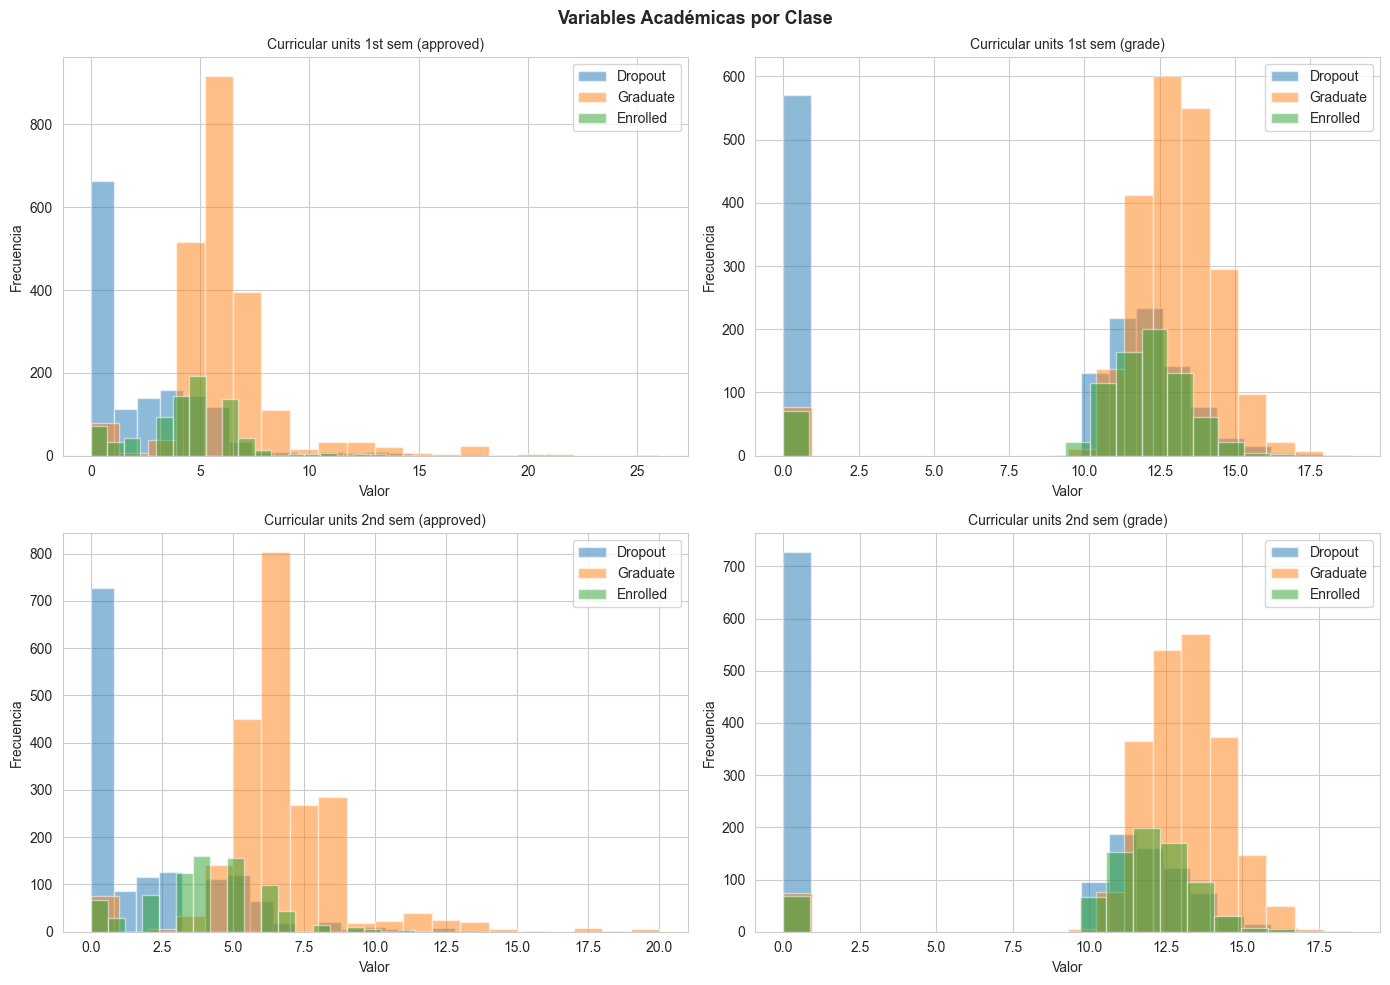

In [18]:
academicas_target = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(academicas_target):
    for target in df['Target'].unique():
        subset = df[df['Target'] == target][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=target)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Variables Académicas por Clase', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

Los gráficos revelan una separación muy clara entre las tres clases,
lo que confirma que el rendimiento académico es el factor más 
discriminante para predecir la situación final del estudiante.

**Materias aprobadas:** en ambos semestres se observa un patrón 
consistente — los estudiantes con 0 materias aprobadas corresponden 
casi exclusivamente a la clase Dropout, mientras que los estudiantes 
que aprueban entre 5 y 6 materias pertenecen predominantemente a 
Graduate. La clase Enrolled se distribuye en valores intermedios, 
lo que tiene sentido ya que son estudiantes que aún continúan su 
proceso académico.

**Promedio de notas:** el patrón se repite — Dropout se concentra 
en nota 0, mientras que Graduate y Enrolled presentan notas entre 
10 y 15. La separación es tan marcada que prácticamente no hay 
superposición entre Dropout y las otras dos clases.

**Comparación entre semestres:** el pico de Dropout en 0 es 
proporcionalmente mayor en el segundo semestre que en el primero, 
lo que sugiere que los estudiantes que no logran recuperarse del 
bajo rendimiento del primer semestre tienen una probabilidad muy 
alta de abandonar.

Estas cuatro variables serán probablemente las más importantes 
para ambos modelos y se espera que tengan alto peso en la 
predicción final.

#### Relación entre Variables Socioeconómicas y la Variable Objetivo

Se analiza si factores como la beca, deudas y situación económica 
del país están asociados con la situación final del estudiante.

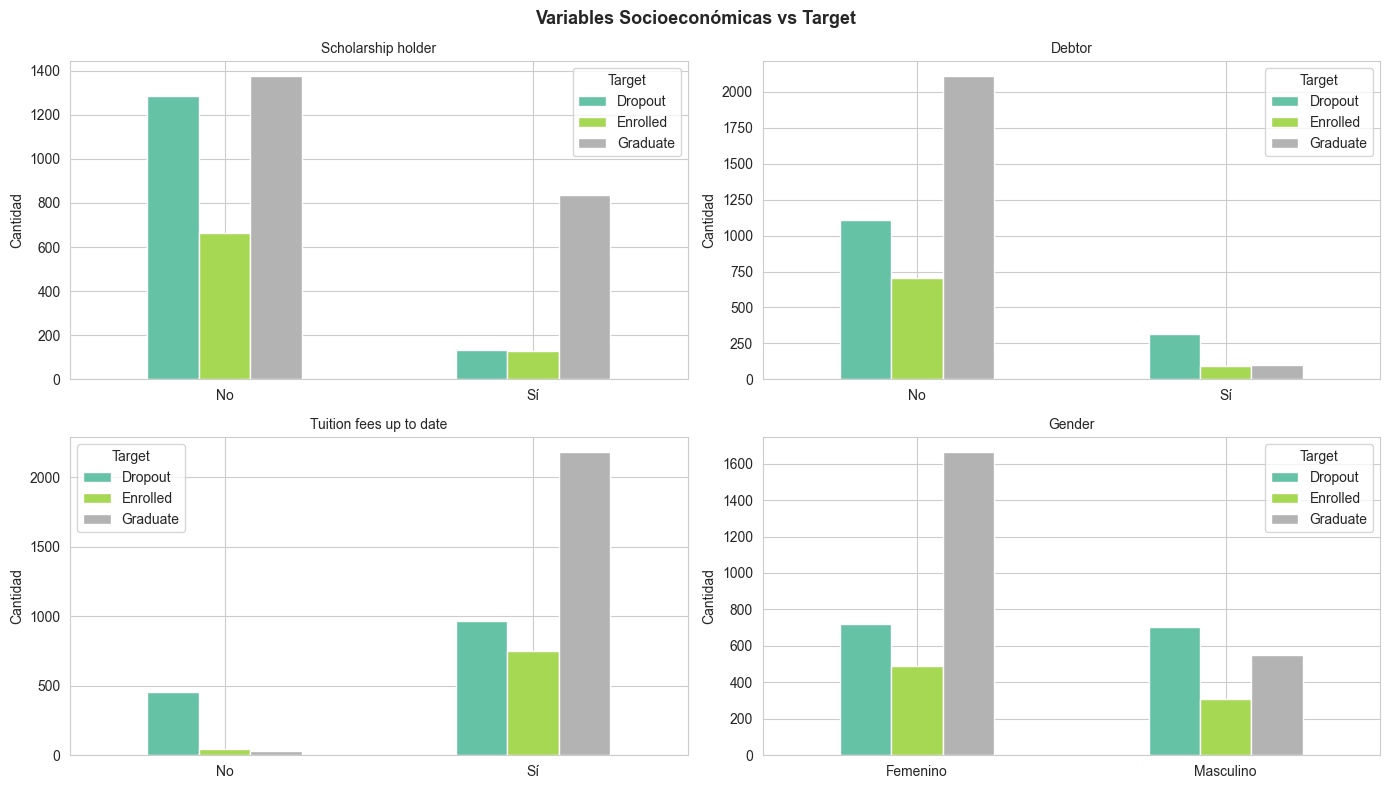

In [33]:
socioeconomicas = ['Scholarship holder', 'Debtor', 
                   'Tuition fees up to date', 'Gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

mapeos_plot = {
    'Scholarship holder': {0: 'No', 1: 'Sí'},
    'Debtor': {0: 'No', 1: 'Sí'},
    'Tuition fees up to date': {0: 'No', 1: 'Sí'},
    'Gender': {0: 'Femenino', 1: 'Masculino'}
}

for i, col in enumerate(socioeconomicas):
    datos = df.groupby([col, 'Target']).size().unstack()
    datos.index = datos.index.map(mapeos_plot[col])
    datos.plot(kind='bar', ax=axes[i], colormap='Set2')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Target')

plt.suptitle('Variables Socioeconómicas vs Target', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

**Pago de matrícula al día:** es la variable más reveladora de este 
análisis. Los estudiantes que NO están al día con el pago muestran 
una proporción de Dropout muy alta comparada con Graduate, mientras 
que los que SÍ están al día tienen Graduate como clase dominante. 
Esto sugiere que las dificultades económicas son un predictor 
directo del abandono.

**Deudas:** un patrón similar — los estudiantes con deudas tienen 
una proporción de Dropout notablemente mayor que los que no deben. 
Confirma que la situación económica está fuertemente asociada 
con el abandono.

**Beca:** los estudiantes con beca tienen una proporción de Graduate 
mayor que los sin beca, lo que sugiere que el apoyo económico 
institucional tiene un efecto protector contra el abandono.

**Género:** no se observan diferencias significativas entre femenino 
y masculino en cuanto a la distribución de clases, lo que indica 
que el género por sí solo no es un predictor relevante del abandono.

#### Matriz de Correlación

Se analiza la correlación entre las variables numéricas del dataset 
para identificar relaciones lineales entre ellas. Esto permite detectar 
variables redundantes que aportan información similar, lo cual es 
relevante para el preprocesamiento y la interpretación del modelo.

c:\Users\USUARIO UNA PZ\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\USUARIO UNA PZ\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


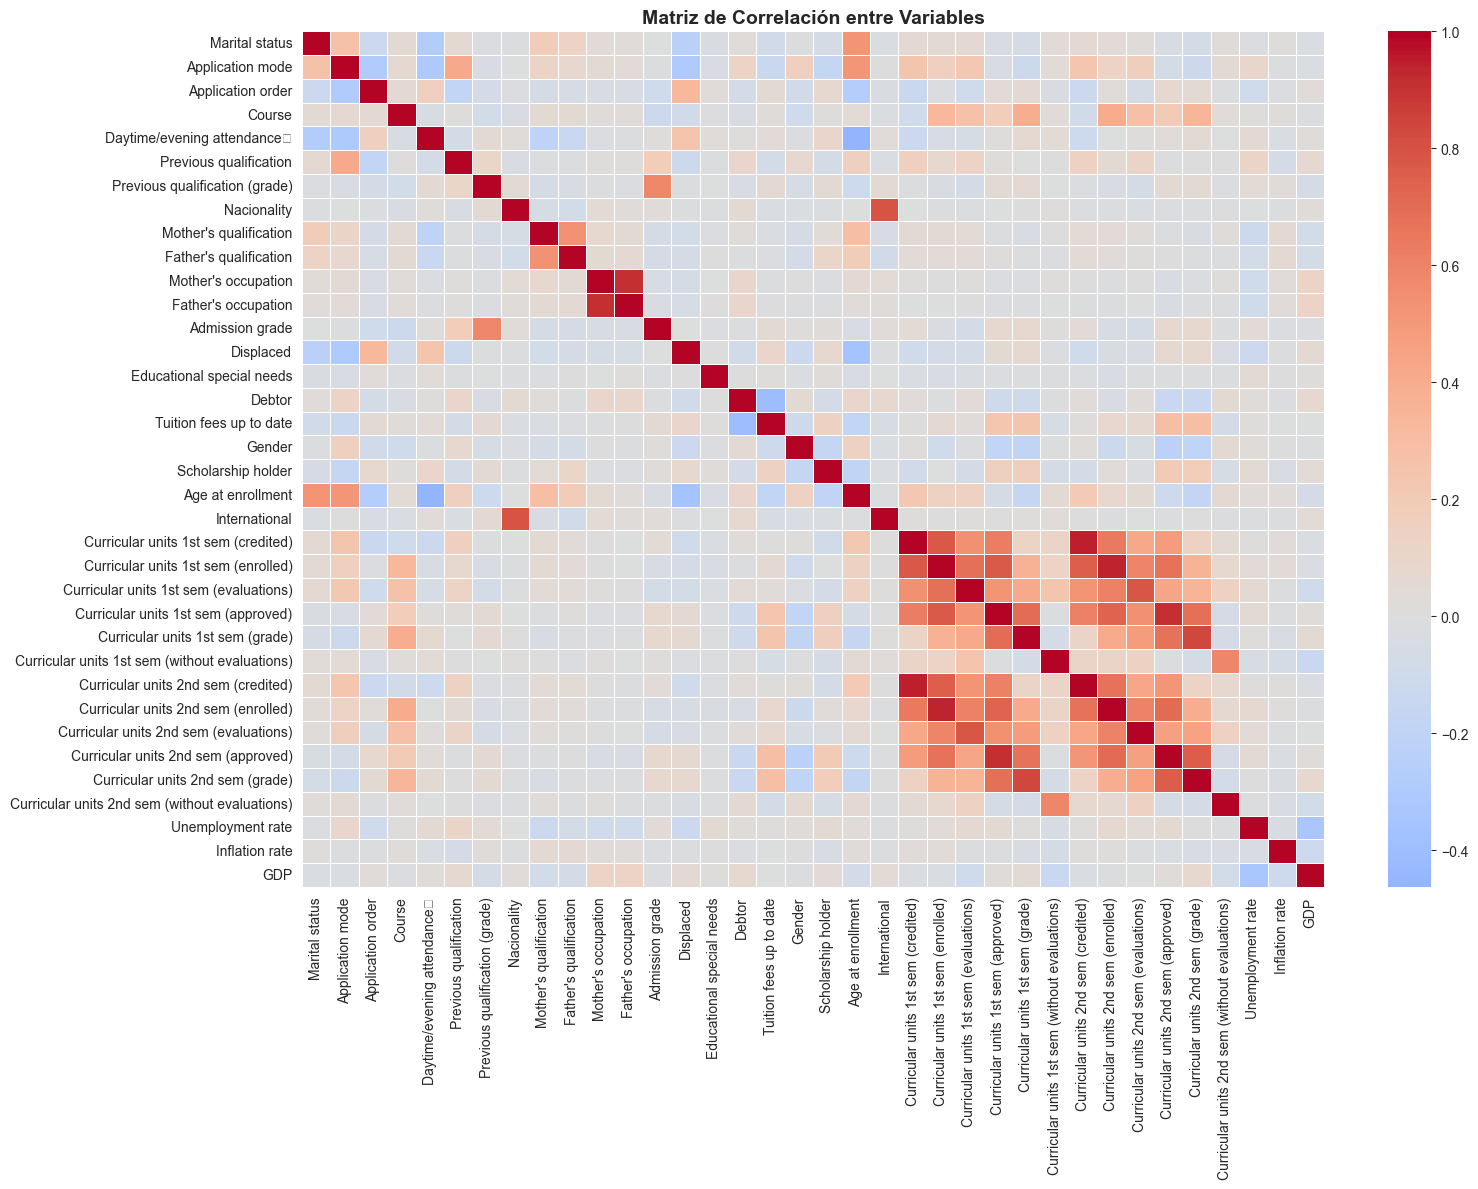

In [19]:
plt.figure(figsize=(16, 12))
correlacion = df.drop(columns=['Target']).corr()

sns.heatmap(correlacion, 
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación entre Variables', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación

La matriz de correlación revela varios patrones importantes:

**Bloque académico:** las variables de rendimiento del primer y segundo 
semestre forman un bloque de alta correlación positiva (rojo oscuro) 
en la esquina inferior derecha. Esto indica que el desempeño del 
primer semestre está fuertemente relacionado con el del segundo — 
estudiantes con buen rendimiento inicial tienden a mantenerlo, y 
viceversa. Esta correlación entre semestres es esperable y tiene 
sentido en el contexto académico real.

Esta alta correlación entre variables del mismo bloque se conoce como 
**multicolinealidad** — fenómeno que ocurre cuando dos o más variables 
aportan información muy similar al modelo, como si estuvieran "diciendo 
lo mismo". Para Random Forest esto no representa un problema ya que el 
algoritmo maneja variables correlacionadas de forma natural. Sin embargo, 
en Regresión Logística puede dificultar la interpretación de los 
coeficientes ya que el modelo no sabe bien cómo distribuir el peso 
entre variables que transmiten información redundante, aspecto que 
se discutirá en el análisis crítico.

**Variables macroeconómicas:** Inflation rate y GDP presentan una 
correlación negativa moderada (azul) entre ellas, lo cual es consistente 
con la relación económica real entre ambos indicadores.

**Variables demográficas y socioeconómicas:** en general muestran 
correlaciones bajas entre sí y con las variables académicas, lo que 
sugiere que aportan información complementaria e independiente al modelo.

### 2.4 Limitaciones del Dataset

A partir del análisis exploratorio realizado, se identifican las 
siguientes limitaciones del dataset:

**Desbalance de clases:** la clase Graduate representa casi el 50% 
de los registros, lo que puede sesgar los modelos hacia predecir 
esta clase con mayor frecuencia. Se abordará mediante 
`class_weight='balanced'` durante el entrenamiento.

**Variables con baja variabilidad:** variables como `Educational 
special needs` (98.8%), `Nacionality` (97.5%) e `International` 
(97.5%) tienen un valor dominante en casi todos los registros, 
lo que limita su capacidad predictiva. Serán candidatas a 
eliminación en el preprocesamiento.

**Contexto geográfico específico:** los datos provienen de una 
sola institución portuguesa, lo que limita la generalización 
del modelo a otros contextos educativos con dinámicas distintas.

**Variables categóricas codificadas:** 18 variables están 
almacenadas como enteros pero representan categorías, lo que 
requiere un tratamiento especial durante el preprocesamiento 
para evitar que el modelo las interprete como valores continuos.

**Período temporal fijo:** las variables macroeconómicas reflejan 
un período específico de Portugal, lo que podría no ser 
representativo de otros contextos económicos.

## 3. Preprocesamiento

El preprocesamiento es el conjunto de transformaciones que se aplican 
al dataset antes de entrenar los modelos. Su objetivo es convertir 
los datos crudos en una representación adecuada para que los 
algoritmos de aprendizaje automático puedan trabajar correctamente.

### 3.1 Eliminación de Variables de Baja Variabilidad

Durante el análisis exploratorio se identificaron tres variables con 
un valor dominante en más del 97% de los registros. Este nivel de 
concentración implica que casi todos los estudiantes tienen el mismo 
valor, por lo que la variable no aporta información útil para 
distinguir entre clases y puede introducir ruido innecesario al modelo.

Las variables eliminadas son:

- `Educational special needs` valor dominante en el 98.8% de registros
- `Nacionality` valor dominante en el 97.5% de registros  
- `International` valor dominante en el 97.5% de registros

In [34]:
# Eliminar variables de baja variabilidad identificadas en el EDA
cols_baja_variabilidad = [
    'Educational special needs',
    'Nacionality',
    'International'
]

df_clean = df.drop(columns=cols_baja_variabilidad)

print(f"Columnas originales: {df.shape[1]}")
print(f"Columnas después de limpieza: {df_clean.shape[1]}")
print(f"Variables eliminadas: {cols_baja_variabilidad}")

Columnas originales: 37
Columnas después de limpieza: 34
Variables eliminadas: ['Educational special needs', 'Nacionality', 'International']


### 3.2 Separación de Features y Target

Antes de cualquier transformación se separan las variables de entrada 
(X) de la variable objetivo (y). Esta separación debe realizarse en 
este punto, después de la limpieza pero antes de dividir los datos
para que todas las operaciones posteriores trabajen únicamente sobre 
las features sin riesgo de modificar accidentalmente la variable 
que se quiere predecir.

- **X** = las 33 características restantes tras la limpieza
- **y** = la columna `Target` con las clases `Dropout`, `Enrolled` 
  y `Graduate`

In [35]:
# Separar features y variable objetivo
X = df_clean.drop(columns=['Target'])
y = df_clean['Target']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nDistribución de clases en y:")
print(y.value_counts())

Dimensiones de X: (4424, 33)
Dimensiones de y: (4424,)

Distribución de clases en y:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


### 3.3 División Entrenamiento y Prueba

Los datos se dividen en dos conjuntos antes de aplicar cualquier 
transformación. Esta decisión es fundamental para garantizar una 
evaluación honesta del modelo, si se transformaran los datos antes 
de dividir, información de los datos de prueba influiría en las 
transformaciones del entrenamiento, contaminando la evaluación lo que se le conoce como data leakage.

Se utiliza una proporción 80/20:

- **Entrenamiento (80%)** = 3,539 registros para que el modelo 
  aprenda los patrones.
- **Prueba (20%)** = 885 registros para evaluar el desempeño 
  con datos nunca vistos.

El parámetro `stratify=y` garantiza que la proporción de cada clase 
(Dropout, Enrolled, Graduate) se mantenga igual en ambos conjuntos, 
lo cual es importante dado el desbalance de clases identificado 
en el análisis exploratorio.

El parámetro `random_state=42` asegura que la división sea 
reproducible, eso significa que cualquier persona que ejecute el notebook obtendrá 
exactamente los mismos conjuntos.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño prueba:        {X_test.shape[0]} registros")
print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True).round(3))

Tamaño entrenamiento: 3539 registros
Tamaño prueba:        885 registros

Distribución de clases en entrenamiento:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Distribución de clases en prueba:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


### 3.4 Clasificación de Variables por Tipo

Una decisión clave del preprocesamiento es distinguir entre dos tipos 
de variables que en este dataset se presentan ambas como números enteros 
pero requieren tratamiento diferente:

**Variables numéricas continuas**: representan magnitudes reales con 
escala y orden significativo. Por ejemplo, `Admission grade` de 95.5 
es mayor que 80.0 en un sentido matemático real. Estas variables se 
escalan con `StandardScaler` para la Regresión Logística.

**Variables categóricas codificadas**: son categorías representadas 
como enteros por conveniencia, pero el número en sí no tiene significado 
matemático. Por ejemplo, `Marital status` con valores 1, 2, 3 no 
significa que el estado civil 3 sea "mayor" que el 1 son simplemente 
etiquetas distintas. Tratarlas como numéricas haría que el modelo 
interprete relaciones de orden que no existen.

In [37]:
# Variables numéricas con escala real
numeric_features = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# Variables categóricas codificadas como enteros
categorical_features = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance\t',
    'Previous qualification',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder'
]

print(f"Variables numéricas:    {len(numeric_features)}")
print(f"Variables categóricas:  {len(categorical_features)}")
print(f"Total:                  {len(numeric_features) + len(categorical_features)}")

Variables numéricas:    18
Variables categóricas:  15
Total:                  33


### 3.5 Construcción de Pipelines de Preprocesamiento

Un Pipeline es una secuencia encadenada de transformaciones que se 
aplican en orden sobre los datos. Su ventaja principal es que garantiza 
que el ajuste (fit) de las transformaciones ocurra únicamente sobre 
los datos de entrenamiento, y que esos mismos parámetros aprendidos 
se apliquen después sobre los datos de prueba, previniendo data leakage.

Los dos modelos seleccionados requieren transformaciones distintas:

| Transformación        | Regresión Logística | Random Forest |
|-----------------------|---------------------|---------------|
| Escalado numérico     | Sí (StandardScaler) | No            |
| Variables categóricas | OneHotEncoder       | OrdinalEncoder|

**Regresión Logística** necesita escalado porque es un modelo basado 
en optimización matemática, variables con escalas muy distintas 
(por ejemplo GDP vs Gender) hacen que el algoritmo converja lentamente 
o asigne pesos distorsionados. El `OneHotEncoder` convierte cada 
categoría en una columna binaria separada, evitando que el modelo 
interprete orden donde no existe.

**Random Forest** no necesita escalado porque los árboles de decisión 
toman decisiones por umbrales (¿es este valor mayor o menor que X?) 
y no se ven afectados por la magnitud de las variables. Se usa 
`OrdinalEncoder` en lugar de `OneHotEncoder` porque es más eficiente 
computacionalmente para árboles y produce el mismo resultado práctico.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# Pipeline para Regresión Logística (con escalado)
preprocessor_lr = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                         sparse_output=False), categorical_features)
])

# Pipeline para Random Forest (sin escalado)
preprocessor_rf = ColumnTransformer(transformers=[
    ('num', 'passthrough', numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value',
                          unknown_value=-1), categorical_features)
])

print("Preprocesador Regresión Logística:")
print(preprocessor_lr)
print("\nPreprocesador Random Forest:")
print(preprocessor_rf)

Preprocesador Regresión Logística:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Previous qualification (grade)',
                                  'Admission grade', 'Age at enrollment',
                                  'Curricular units 1st sem (credited)',
                                  'Curricular units 1st sem (enrolled)',
                                  'Curricular units 1st sem (evaluations)',
                                  'Curricular units 1st sem (approved)',
                                  'Curricular units 1st sem (grade)',
                                  'Curricular units 1st sem (without '
                                  'evaluations)',
                                  'Curricular...
                                  'GDP']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
      

### 3.6 Verificación del Preprocesamiento

Antes de proceder al entrenamiento se verifica que ambos pipelines 
funcionan correctamente aplicándolos sobre el conjunto de 
entrenamiento. Se comprueba que las dimensiones resultantes sean 
coherentes con las transformaciones aplicadas.

El preprocesador de Regresión Logística genera más columnas que el 
de Random Forest porque el `OneHotEncoder` expande cada variable 
categórica en múltiples columnas binarias, una por cada categoría 
posible. El `OrdinalEncoder` en cambio mantiene una sola columna 
por variable.

In [39]:
# Verificar preprocesador de Regresión Logística
X_train_lr = preprocessor_lr.fit_transform(X_train)
X_test_lr  = preprocessor_lr.transform(X_test)

print("=== Regresión Logística ===")
print(f"Train: {X_train_lr.shape}")
print(f"Test:  {X_test_lr.shape}")

# Verificar preprocesador de Random Forest
X_train_rf = preprocessor_rf.fit_transform(X_train)
X_test_rf  = preprocessor_rf.transform(X_test)

print("\n=== Random Forest ===")
print(f"Train: {X_train_rf.shape}")
print(f"Test:  {X_test_rf.shape}")

=== Regresión Logística ===
Train: (3539, 228)
Test:  (885, 228)

=== Random Forest ===
Train: (3539, 33)
Test:  (885, 33)


## 4. Implementación de Modelos

En esta sección se implementan los dos modelos de clasificación 
seleccionados. Cada modelo se entrena con los datos preprocesados 
correspondientes y se obtiene un resultado inicial que será analizado 
en profundidad en la sección de evaluación experimental.

### 4.1 Modelo 1 — Regresión Logística

La Regresión Logística es un modelo lineal que estima la probabilidad 
de pertenencia a cada clase. Para clasificación multiclase aplica 
la función softmax, que convierte las salidas lineales en 
probabilidades que suman 1:

$$P(y = k \mid x) = \frac{e^{w_k \cdot x}}{\sum_{j} e^{w_j \cdot x}}$$

Se selecciona como modelo base por ser interpretable matemáticamente, 
computacionalmente eficiente, y por establecer un punto de referencia 
mínimo que cualquier modelo más complejo debería superar.

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Definir el modelo
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Entrenar
lr_model.fit(X_train_lr, y_train)

# Predecir
y_pred_lr = lr_model.predict(X_test_lr)

print("=== Regresión Logística — Resultado Inicial ===")
print(classification_report(y_test, y_pred_lr))

=== Regresión Logística — Resultado Inicial ===
              precision    recall  f1-score   support

     Dropout       0.82      0.69      0.75       284
    Enrolled       0.41      0.63      0.50       159
    Graduate       0.86      0.79      0.82       442

    accuracy                           0.73       885
   macro avg       0.70      0.70      0.69       885
weighted avg       0.77      0.73      0.74       885



#### Resultado Inicial

El modelo alcanza una exactitud global del 73%. Sin embargo, el 
desempeño varía considerablemente entre clases:

- **Graduate (F1: 0.82)** — es la clase mejor predicha, 
  consistente con ser la más representada en el dataset (442 casos).
- **Dropout (F1: 0.75)** — el modelo la detecta con buena precisión 
  (0.82), aunque el recall de 0.69 indica que hay estudiantes en 
  riesgo que no está identificando correctamente.
- **Enrolled (F1: 0.50)** — es la clase más difícil para el modelo. 
  Con solo 159 casos en el test y siendo la clase minoritaria, el 
  modelo la confunde frecuentemente con las otras dos clases. Esto 
  es consistente con el desbalance identificado en el análisis 
  exploratorio.

Estos resultados base serán comparados formalmente con Random Forest 
en la sección de evaluación experimental.

### 4.2 Modelo 2 — Random Forest

Random Forest es un algoritmo de aprendizaje en conjunto (ensemble) 
que construye múltiples árboles de decisión durante el entrenamiento 
y combina sus predicciones por votación mayoritaria. Cada árbol 
se entrena sobre una muestra aleatoria del dataset y considera 
solo un subconjunto aleatorio de variables en cada división, 
lo que reduce la correlación entre árboles y mejora la generalización.

Se selecciona por tres razones principales:
- Maneja simultáneamente variables numéricas y categóricas sin 
  requerir escalado.
- Es resistente al sobreajuste gracias a la agregación de múltiples 
  árboles.
- Permite obtener la importancia relativa de cada variable, lo cual 
  es valioso para entender qué factores influyen más en el abandono 
  escolar.

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Definir el modelo
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Entrenar
rf_model.fit(X_train_rf, y_train)

# Predecir
y_pred_rf = rf_model.predict(X_test_rf)

print("=== Random Forest — Resultado Inicial ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest — Resultado Inicial ===
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.78       284
    Enrolled       0.55      0.32      0.41       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



#### Resultado Inicial

El modelo alcanza una exactitud global del 76%, superando a la 
Regresión Logística en 3 puntos porcentuales. El comportamiento 
por clase muestra un patrón diferente al modelo anterior:

- **Graduate (F1: 0.85)** — es la clase mejor predicha, con un 
  recall de 0.93 que indica que el modelo identifica correctamente 
  la gran mayoría de estudiantes que se gradúan.
- **Dropout (F1: 0.78)** — mejora respecto a la Regresión Logística, 
  con un recall de 0.75 que representa una detección más equilibrada 
  de estudiantes en riesgo.
- **Enrolled (F1: 0.41)** — sigue siendo la clase más difícil. 
  A pesar de una precision de 0.55, el recall de 0.32 indica que 
  el modelo solo detecta 1 de cada 3 estudiantes activos, 
  confundiéndolos frecuentemente con las otras clases.

El weighted avg F1 de 0.75 es comparable al de Regresión Logística 
(0.74), aunque con una distribución del error diferente entre clases. 
La comparación formal se realizará en la sección de evaluación 
experimental.